In [1]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
# Cell 2: Load the data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("✅ Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

✅ Data loaded successfully!
Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Cell 3: Data overview
print("=== DATASET INFO ===\n")
print(df.info())

print("\n=== BASIC STATISTICS ===\n")
print(df.describe())

print("\n=== COLUMN NAMES ===\n")
print(df.columns.tolist())

=== DATASET INFO ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [6]:
# Cell 4: Check TotalCharges specifically
print("First 10 values of TotalCharges:")
print(df['TotalCharges'].head(10))

print(f"\nData type of TotalCharges: {df['TotalCharges'].dtype}")

# Check for empty strings or special values
print(f"\nUnique values in TotalCharges (first 20):")
print(df['TotalCharges'].unique()[:20])

# Check if there are any empty strings
empty_strings = (df['TotalCharges'] == ' ').sum()
print(f"\nNumber of empty strings: {empty_strings}")

# Try to convert to numeric and see what fails
try:
    pd.to_numeric(df['TotalCharges'])
    print("\n✅ Can be converted to numeric without issues!")
except Exception as e:
    print(f"\n❌ Conversion error: {e}")
    
    # Find which values can't be converted
    non_numeric = []
    for value in df['TotalCharges'].unique():
        try:
            pd.to_numeric(value)
        except:
            non_numeric.append(value)
    
    print(f"Values causing issues: {non_numeric}")

First 10 values of TotalCharges:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

Data type of TotalCharges: object

Unique values in TotalCharges (first 20):
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

Number of empty strings: 11

❌ Conversion error: Unable to parse string " " at position 488
Values causing issues: [' ']


In [7]:
# Cell 5: Clean TotalCharges column
print("Before cleaning:")
print(f"TotalCharges data type: {df['TotalCharges'].dtype}")
print(f"Number of empty strings: {(df['TotalCharges'] == ' ').sum()}")
print(f"Number of null values: {df['TotalCharges'].isnull().sum()}")

# Convert empty strings to NaN first
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Now convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print("\nAfter cleaning:")
print(f"TotalCharges data type: {df['TotalCharges'].dtype}")
print(f"Number of null values: {df['TotalCharges'].isnull().sum()}")

# Check the 11 rows that had empty strings
null_rows = df[df['TotalCharges'].isnull()]
print(f"\nRows with null TotalCharges after conversion:")
print(null_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

# For these customers with tenure = 0, TotalCharges should be 0
# Let's fill nulls with 0 * MonthlyCharges (which is 0 for tenure=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"\nAfter filling nulls with 0:")
print(f"Number of null values: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges stats:\n{df['TotalCharges'].describe()}")

Before cleaning:
TotalCharges data type: object
Number of empty strings: 11
Number of null values: 0

After cleaning:
TotalCharges data type: float64
Number of null values: 11

Rows with null TotalCharges after conversion:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN

After filling nulls with 0:
Number of null values: 0
TotalCharges stats:
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


=== CHURN DISTRIBUTION ===

Counts:
  No Churn:  5174
  Churn:     1869

Percentages:
  No Churn:  73.5%
  Churn:     26.5%


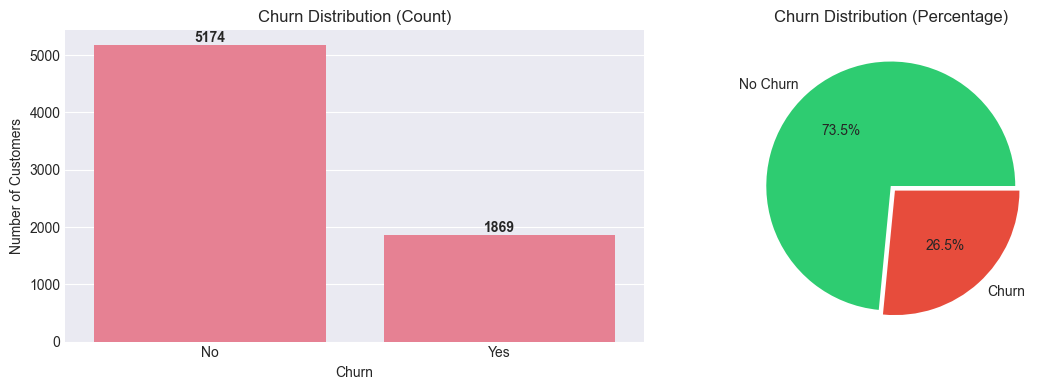

In [8]:
# Cell 6: Analyze target variable (Churn)
print("=== CHURN DISTRIBUTION ===\n")
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print(f"Counts:")
print(f"  No Churn:  {churn_counts['No']}")
print(f"  Churn:     {churn_counts['Yes']}")
print(f"\nPercentages:")
print(f"  No Churn:  {churn_percentages['No']:.1f}%")
print(f"  Churn:     {churn_percentages['Yes']:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Number of Customers')

# Add count labels on bars
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                labels=['No Churn', 'Churn'],
                                colors=colors,
                                ax=axes[1],
                                explode=[0, 0.05])  # Slightly explode the churn slice
axes[1].set_title('Churn Distribution (Percentage)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\Soham Jathar\AppData\Local\Temp\ipykernel_9280\34178939.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],
C:\Users\Soham Jathar\AppData\Local\Temp\ipykernel_9280\34178939.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],



tenure Statistics:
        mean  median    std
Churn                      
No     37.57    38.0  24.11
Yes    17.98    10.0  19.53

MonthlyCharges Statistics:
        mean  median    std
Churn                      
No     61.27   64.43  31.09
Yes    74.44   79.65  24.67


C:\Users\Soham Jathar\AppData\Local\Temp\ipykernel_9280\34178939.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],



TotalCharges Statistics:
          mean   median      std
Churn                           
No     2549.91  1679.52  2329.95
Yes    1531.80   703.55  1890.82


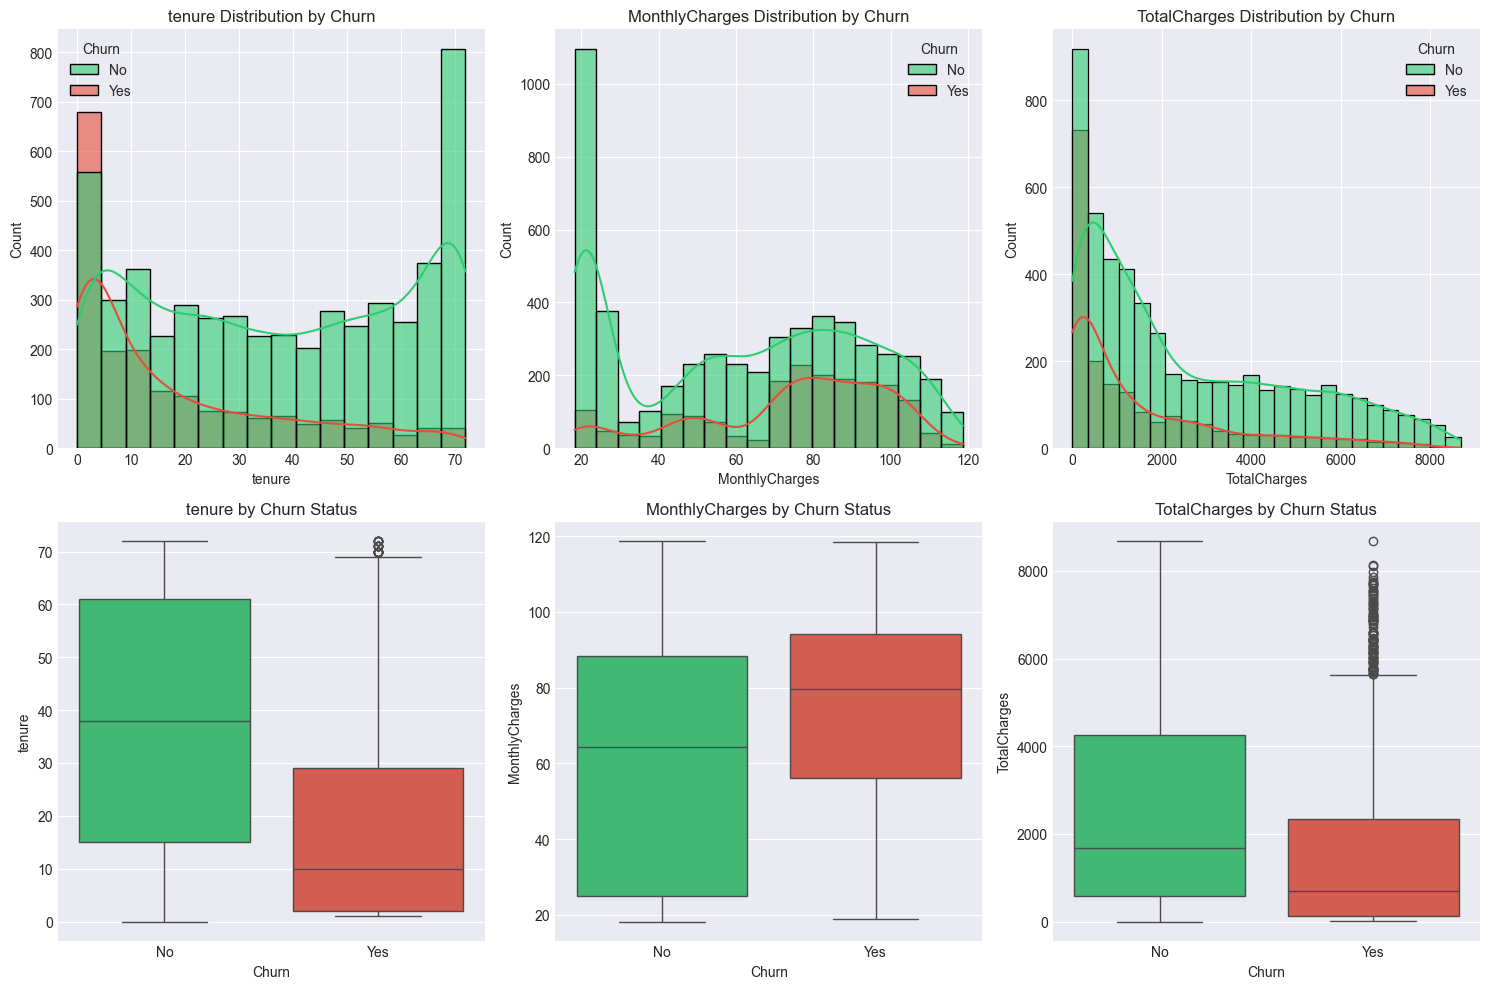

In [9]:
# Cell 7: Numerical Features Analysis
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    # Histogram with hue
    sns.histplot(data=df, x=col, hue='Churn', kde=True, 
                 ax=axes[0, i], alpha=0.6, palette=['#2ecc71', '#e74c3c'])
    axes[0, i].set_title(f'{col} Distribution by Churn')
    
    # Box plot
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],
                palette=['#2ecc71', '#e74c3c'])
    axes[1, i].set_title(f'{col} by Churn Status')
    
    # Add statistics
    stats = df.groupby('Churn')[col].agg(['mean', 'median', 'std']).round(2)
    print(f"\n{col} Statistics:")
    print(stats)

plt.tight_layout()
plt.show()


Contract - Churn Rates:
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8

InternetService - Churn Rates:
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4

PaymentMethod - Churn Rates:
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1

TechSupport - Churn Rates:
Churn                  No   Yes
TechSupport                    
No                   58.4  41.6
No internet service  92.6   7.4
Yes                  84.8  15.2


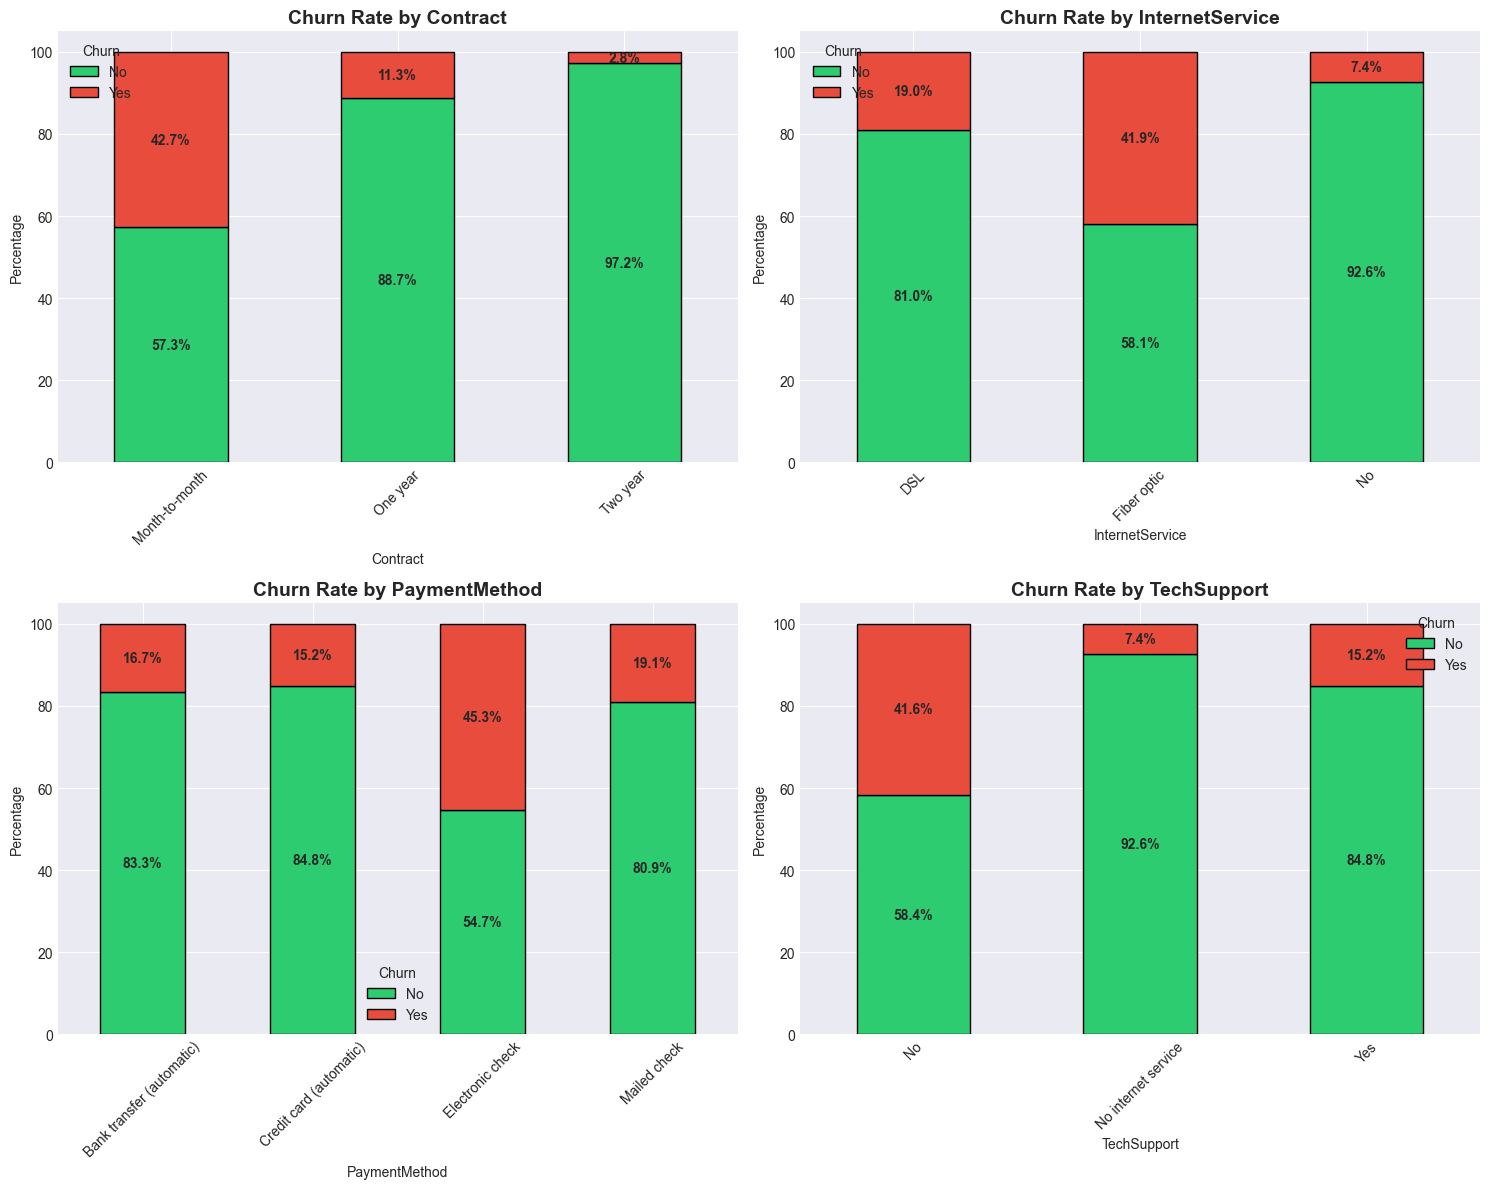

In [10]:
# Cell 8: Categorical Features Analysis
important_cats = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(important_cats):
    # Create crosstab with percentages
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    
    # Plot
    ct.plot(kind='bar', stacked=True, ax=axes[i], 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Churn')
    
    # Add value labels
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', label_type='center', fontweight='bold')
    
    # Rotate x-axis labels if needed
    axes[i].tick_params(axis='x', rotation=45)
    
    # Print statistics
    print(f"\n{'='*50}")
    print(f"{col} - Churn Rates:")
    print(f"{'='*50}")
    print(ct.round(1))

plt.tight_layout()
plt.show()